In [2]:
import sys
sys.path.append("/Users/sophia/Desktop/Fundamentals_of_Bioinformatics/BioInfoFinalProject")

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import anndata as ad
import seaborn as sns
import scanpy as sc
import warnings
warnings.filterwarnings("ignore", category = UserWarning, module = "openpyxl")
from trajectory_inference.Laplacian_Eigenmaps import fullLaplacian, revelio_like_preprocess

G1/S 96 ['ACD', 'ACYP1', 'ADAMTS1', 'ANKRD10', 'APEX2', 'ARGLU1', 'ATAD2', 'BARD1', 'BRD7', 'C14orf142']
S 110 ['ABCC5', 'ABHD10', 'ANKRD18A', 'ASF1B', 'ATAD2', 'BBS2', 'BIVM', 'BLM', 'BMI1', 'BRCA1']
G2/M 132 ['ANLN', 'AP3D1', 'ARHGAP19', 'ARL4A', 'ARMC1', 'ASXL1', 'ATL2', 'AURKB', 'BCLAF1', 'BORA']
M 150 ['AHI1', 'AKIRIN2', 'ANKRD40', 'ANLN', 'ANP32B', 'ANP32E', 'ARHGAP19', 'ARL6IP1', 'ASXL1', 'ATF7IP']
M/G1 105 ['AGFG1', 'AGPAT3', 'AKAP13', 'AMD1', 'ANP32E', 'ANTXR1', 'BAG3', 'BTBD3', 'CBX3', 'CDC42']
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
Embedding shape (677, 2)
Pseudotime range 0.0 0.04649055559928367
Eigenvalues: [0.06454681 0.10290085]


In [4]:
# loading in data and gene phase markers
data = pd.read_csv("../data/GSE142277/GSM4224315_out_gene_exon_tagged.dge_exonssf002_WT.txt", sep = "\t", index_col = 0)
geneData = pd.ExcelFile("../data/GSE142277/gene_sets_GSE142277.xlsx")
geneSets = geneData.parse("Gene Sets Used in Analysis")

In [5]:
# processing data with revelio like processing function
marker_dict = {}
for cc in geneSets.columns:
    marker_dict[cc] = list(geneSets[cc].dropna().apply(lambda x: x.strip()).values)
adata = revelio_like_preprocess(data, marker_dict)

G1/S 96 ['ACD', 'ACYP1', 'ADAMTS1', 'ANKRD10', 'APEX2', 'ARGLU1', 'ATAD2', 'BARD1', 'BRD7', 'C14orf142']
S 110 ['ABCC5', 'ABHD10', 'ANKRD18A', 'ASF1B', 'ATAD2', 'BBS2', 'BIVM', 'BLM', 'BMI1', 'BRCA1']
G2/M 132 ['ANLN', 'AP3D1', 'ARHGAP19', 'ARL4A', 'ARMC1', 'ASXL1', 'ATL2', 'AURKB', 'BCLAF1', 'BORA']
M 150 ['AHI1', 'AKIRIN2', 'ANKRD40', 'ANLN', 'ANP32B', 'ANP32E', 'ARHGAP19', 'ARL6IP1', 'ASXL1', 'ATF7IP']
M/G1 105 ['AGFG1', 'AGPAT3', 'AKAP13', 'AMD1', 'ANP32E', 'ANTXR1', 'BAG3', 'BTBD3', 'CBX3', 'CDC42']


Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...


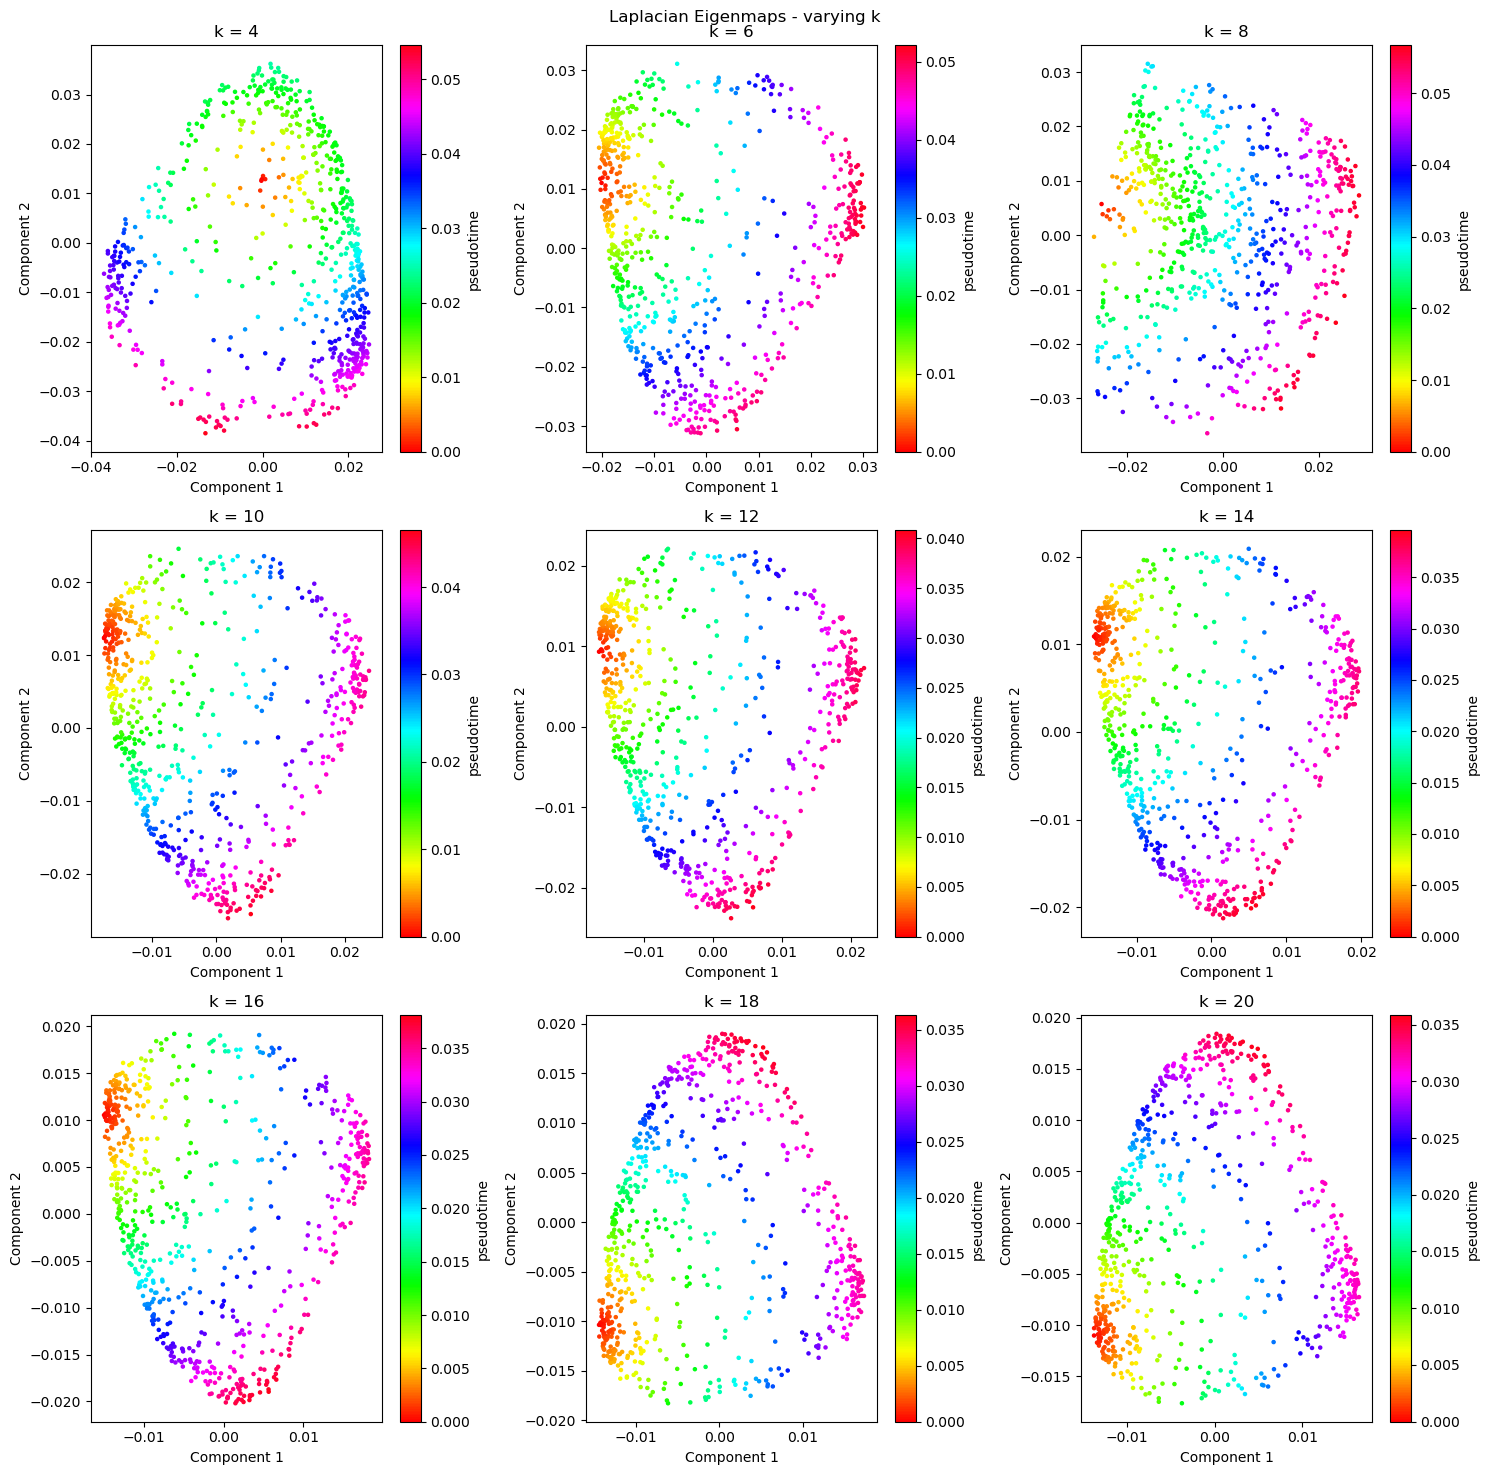

In [6]:
# embedding plots with varying k clusters in kNN

kVals = list(range(4, 22, 2))
fig, axes = plt.subplots(3, 3, figsize = (15, 15))
axes = axes.flatten()

for i, k in enumerate(kVals):
    embeddings, eigvals, ps = fullLaplacian(adata, k = k)
    sc = axes[i].scatter(embeddings[:, 0], embeddings[:, 1], c = ps, cmap = "hsv", s = 5)
    axes[i].set_title(f"k = {k}")
    axes[i].set_xlabel("Component 1")
    axes[i].set_ylabel("Component 2")
    plt.colorbar(sc, ax = axes[i], label = "pseudotime")

plt.suptitle("Laplacian Eigenmaps - varying k")
plt.tight_layout()
# fig.savefig("../../lapSubplots.png", dpi = 150, bbox_inches = "tight")
plt.show()

Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...


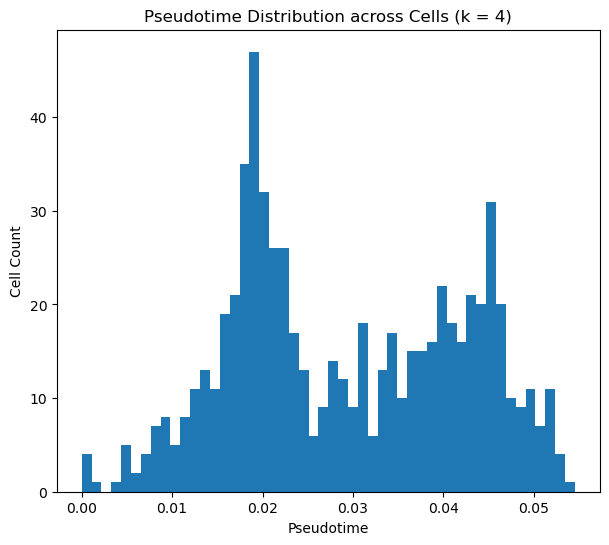

In [8]:
# plot of pseudotime distribution
embeddings, eigvals, pseudo = fullLaplacian(adata, k = 4)

plt.figure(figsize = (7, 6))
plt.hist(pseudo, bins = 50)
plt.xlabel("Pseudotime")
plt.ylabel("Cell Count")
plt.title(f"Pseudotime Distribution across Cells (k = 4)")
plt.show()

/var/folders/dw/g18q38015s903bx123vgtd5c0000gn/T/ipykernel_84697/3463460622.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data = plotDF, x = "pseudotime", y = "phase", order = phases, palette = "Set1", ax = ax)


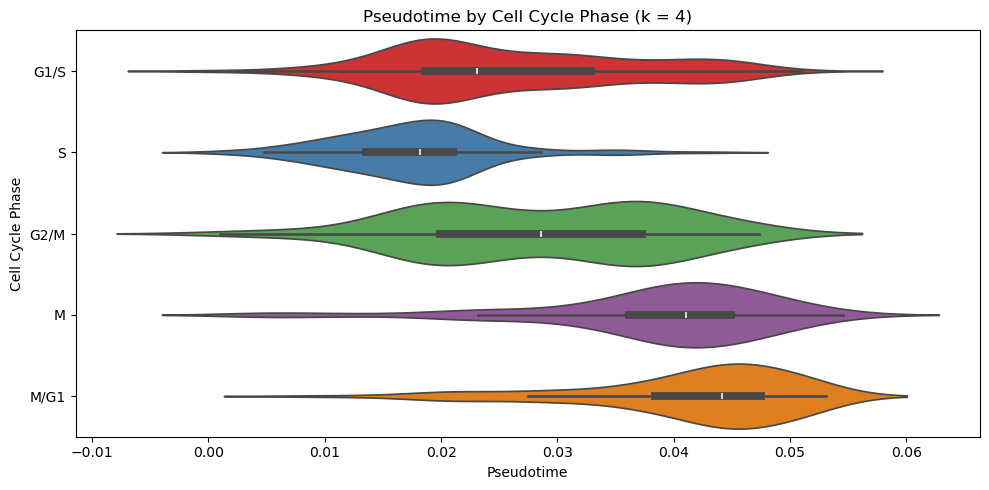

In [9]:
### cell cycle phase vs pseudotime of cells

phases = ["G1/S", "S", "G2/M", "M", "M/G1"]
# making dataframe with pseudotime and phase assignment of each cell
plotDF = pd.DataFrame({"pseudotime": pseudo, "phase": adata.obs["cc_phase"].values})

# violin plot pseudotime vs cell cycle phase
fig, ax = plt.subplots(figsize = (10, 5))
sns.violinplot(data = plotDF, x = "pseudotime", y = "phase", order = phases, palette = "Set1", ax = ax)
ax.set_xlabel("Pseudotime")
ax.set_ylabel("Cell Cycle Phase")
ax.set_title("Pseudotime by Cell Cycle Phase (k = 4)")
plt.tight_layout()
plt.show()

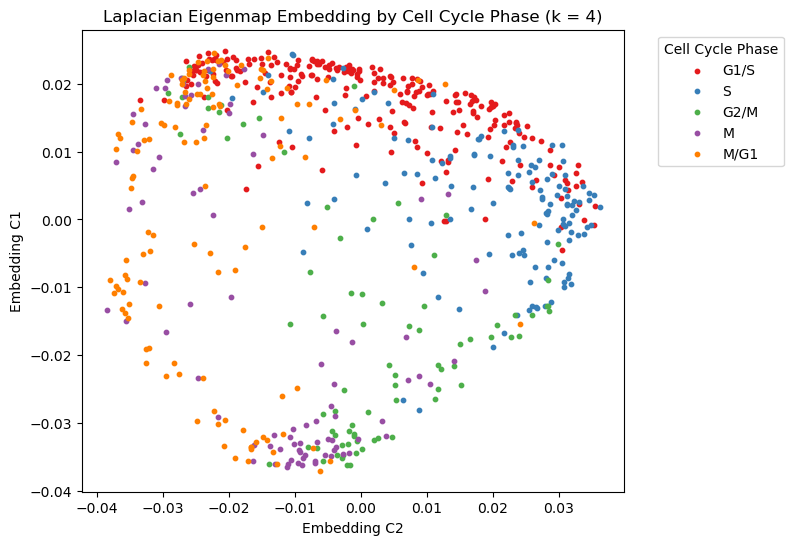

In [10]:
# circular embedding with cell cycle phase labels

phases = ["G1/S", "S", "G2/M", "M", "M/G1"]
colors = sns.color_palette("Set1", len(phases))

fig, ax = plt.subplots(figsize = (7, 6))

for phase, color in zip(phases, colors):
    mask = adata.obs["cc_phase"] == phase
    ax.scatter(embeddings[mask, 1], embeddings[mask, 0], label = phase, color = color, s = 10)

ax.set_title("Laplacian Eigenmap Embedding by Cell Cycle Phase (k = 4)")
ax.set_xlabel("Embedding C2")
ax.set_ylabel("Embedding C1")
ax.legend(title = "Cell Cycle Phase", bbox_to_anchor = (1.05, 1), loc = "upper left")
fig.savefig("../../lapEmvsCC.png")
plt.show()